Автор файла - Артём Коновалов (artem.konovalov.2001@yandex.ru)

# Тестовое задание

<b>Написать скрипт на python, скрипт должен формировать датафрейм из 6 колонок и не менее 5 млн строк </b>

структура датафрейма 

1. date дата события (2025-01-01- 2025-12-31)

2. event название события может принимать значения view, purchase, add_to_cart

3. device_id идентификатор устойства guid

4. event_time дата и время события "2025-01-01 12:12:21"

5. city город в котором находится клиент (Москва, Новосиьбисрк, Тула,...)

6. device_os ОC устройства клиента (Android,iOS)

Далее скрипт должен создать таблицу применик в ClickHouse и зарузить данные в таблицу применик в ClickHouse

# Описание решения

## 1. Генерация данных
В качестве основного технологического решения дял генерации была выбрана комбинация numpy + pandas с исходными списками городов, событий и девайсов. При увеличении объема данных до 100 млн+ строк и переходе на распределенную обработку, логика генерации может быть легко перенесена на PySpark, что позволит генерировать данные параллельно на узлах кластера.

Для того, чтобы избежать конфликтов и нелогичных данных, предусмотрена реализация сущностей - пользователей (девайсов). Это позволило избежать неккоректных данных, <i>телепортации</i> пользователя, разных девайсов в один и тот же промежуток времени, если бы мы генерировали просто рандомные данные. 

Комментарии по полям таблицы:
* **'date', 'event_time', 'event'.** Для имитации естественной человеческиой задержки между взаимодействиями, события event разделены таким образом, чтобы между событиями для каждого пользователя проходило как минимум 5 секунд. Логика хронологического порядка **view --> add_to_cart --> purchase** для действий пользователей не предусмотрена, так как нет **item_id** - поля, по которому можно было бы понять что это за товар. Считаем что пользователь мог проводить эти действия для разных товаров. Например, купить один товар (purchase), затем добавить другие товары в корзину (add_to cart), которые мог даже не просматривать (view) и тп. 

* **'city'.** Список городов CITIES был сокращен для демонстрации работоспособности. Можно легко загрузить список городов из какого-нибудь справочника или API.

* **'device_id'.** Реализован с помощью uuid.

* **'device_os'**. В рамках данной модели за каждым уникальным идентификатором устройства закреплена одна операционная система. Для упрощения модели и в связи с отсутствием поля user_id (идентификатор пользователя), сценарий использования одним пользователем нескольких устройств с разными ОС не рассматривается.

Часто повторяющиеся типы данных, такие как city, event, device_os были приведены к формату Category.

Количество записей = 5 050 000 строк.  
Количество пользователей будем считать в 10 раз меньше.

## 2. Загрузка данных в ClickHouse
<font color= "PaleVioletRed">Для обеспечения гибкости и безопасности при проверке задания, конфигурация подключения вынесена в отдельный блок. Параметры доступа (Host, Port, User, Password) вводятся пользователем перед запуском и не хранятся в коде в открытом виде.</font>

Описание процесса загрузки:
1. Создание таблицы events в ClickHouse (или проверка, создана ли эта таблица)
2. Так как генератор каждый раз создает полностью новый массив случайных данных, реализована принудительная очистка таблицы перед вставкой. Это гарантирует, что в базе будут находиться только актуальные результаты последнего прогона.
3. Загрузка осуществляется методом insert_df, который сопоставляет типы Pandas и ClickHouse.

Результат успешного выполнения и состояние таблицы в интерфейсе ClickHouse представлены в конце данного notebook.

In [ ]:
# Настрйоки подключения к ClickHouse
# Введите ваши данные
CH_HOST = '<CH_HOST>' 
CH_PORT = 8443     
CH_USERNAME = 'default'
CH_PASSWORD = '<CH_PASSWORD>'

In [5]:
import pandas as pd
import numpy as np
import uuid
from datetime import datetime
from IPython.display import display
import clickhouse_connect

N = 5050500 # Количество записей
N_U = int(N/10) # Количество пользователей

class DataGenerator:
    """
    Класс для генерации сущностей.
    """
    def __init__(self, n_rows=5050500, n_unique_users=505000):
        self.n_rows = n_rows
        self.n_unique_users = n_unique_users
        self.cities = ['Москва', 'Санкт-Петербург', 'Краснодар', 'Сочи', "Новосибирск", 'Казань', 'Ростов-на-Дону']
        self.os_types = ['iOS', 'Android']
        self.events = ['view', 'purchase', 'add_to_cart']

    def generate(self):

        # Генерация мастер-данных пользователей
        # Это гарантирует, что device_id привязан к городу и ОС

        unique_user_ids = [str(uuid.uuid4()) for _ in range(self.n_unique_users)]
        user_cities = np.random.choice(self.cities, size=self.n_unique_users)
        user_os = np.random.choice(self.os_types, size=self.n_unique_users)
        
        # 2. Формирование основы датафрейма
        indices = np.random.randint(0, self.n_unique_users, size=self.n_rows)
        
        df = pd.DataFrame({
            'device_id': np.take(unique_user_ids, indices),
            'city': np.take(user_cities, indices),
            'device_os': np.take(user_os, indices),
            'event': np.random.choice(self.events, size=self.n_rows)
        })

        # Генерация времени с логикой задержки в 5 секунд
        
        # Задаем базовое случайное время для каждого события в рамках 2025 года
        start_time = np.datetime64('2025-01-01T00:00:00')
        # Генерируем случайный начальный сдвиг в секундах для каждого события (в году 31 536 000 секунд)
        df['base_offset'] = np.random.randint(0, 31536000, size=self.n_rows)
        
        # Сортируем по пользователю, чтобы применить кумулятивную задержку
        df = df.sort_values(by=['device_id', 'base_offset'])
        
        # Для каждого пользователя берем его порядковый номер события и умножаем на 5 секунд. Так мы гарантируем минимум 5 секунд между действиями.
        df['seq_delay'] = df.groupby('device_id').cumcount() * 5
        
        # Итоговое время event_time
        df['event_time'] = start_time + pd.to_timedelta(df['base_offset'] + df['seq_delay'], unit='s')
        
        # date
        df['date'] = df['event_time'].dt.date
        df['date'] = pd.to_datetime(df['date'])
        # Формирование df
        df = df[['device_id', 'date', 'event', 'event_time', 'city', 'device_os']]
        
        for col in ['event', 'city', 'device_os']:
            df[col] = df[col].astype('category')

        return df

generator = DataGenerator(n_rows=N, n_unique_users=N_U)
df = generator.generate()

print("\nДатафрейм создан")
print(f"Размер датафрейма в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df.head(5))


Датафрейм создан
Размер датафрейма в памяти: 539.45 MB


,device_id,date,event,event_time,city,device_os
4971182,0000136c-274f-4e89-a94e-acfcf404a25b,2025-01-10,add_to_cart,2025-01-10 17:49:32,Ростов-на-Дону,iOS
4833045,0000136c-274f-4e89-a94e-acfcf404a25b,2025-02-26,view,2025-02-26 06:05:49,Ростов-на-Дону,iOS
920063,0000136c-274f-4e89-a94e-acfcf404a25b,2025-03-01,add_to_cart,2025-03-01 06:51:09,Ростов-на-Дону,iOS
22282,0000136c-274f-4e89-a94e-acfcf404a25b,2025-04-13,add_to_cart,2025-04-13 11:21:46,Ростов-на-Дону,iOS
847448,0000136c-274f-4e89-a94e-acfcf404a25b,2025-06-15,add_to_cart,2025-06-15 09:27:33,Ростов-на-Дону,iOS


In [7]:
class ClickHouseLoader:
    def __init__(self, host, port, username, password):
        self.client = clickhouse_connect.get_client(host=host, port=port, username=username, password=password, secure=True)
        print(f"Успешное подключение к ClickHouse ({host})")
 

    def create_table(self):
        query = """
        CREATE TABLE IF NOT EXISTS events (
            device_id UUID,
            date Date,
            event LowCardinality(String),
            event_time DateTime,
            city LowCardinality(String),
            device_os LowCardinality(String)
        ) ENGINE = MergeTree()
        ORDER BY (device_id, event_time);
        """
        self.client.command(query)
        print("Таблица проверена/создана.")
        
        self.client.command("TRUNCATE TABLE events")
        print("Таблица готова (старые данные удалены).")

    def load_data(self, df):
        self.client.insert_df('events', df)
        print("Загрузка завершена.")
        
    def validate_data(self):
        count = self.client.query("SELECT count() FROM events").result_rows[0][0]
        print(f"В таблице: {count} строк.")
        
try:
    loader = ClickHouseLoader(host=CH_HOST, port=CH_PORT, username=CH_USERNAME, password=CH_PASSWORD)
    loader.create_table()
    loader.load_data(df)
    loader.validate_data()
    print('На скриншоте ниже приведено окно ClickHouse после успешной загрузки данных.')

except Exception as e:
    print(f'Ошибка подключения: {e}')

Успешное подключение к ClickHouse (v1u17s9mdv.eu-central-1.aws.clickhouse.cloud)
Таблица проверена/создана.
Таблица готова (старые данные удалены).
Загрузка завершена.
В таблице: 5050500 строк.
На скриншоте ниже приведено окно ClickHouse после успешной загрузки данных.


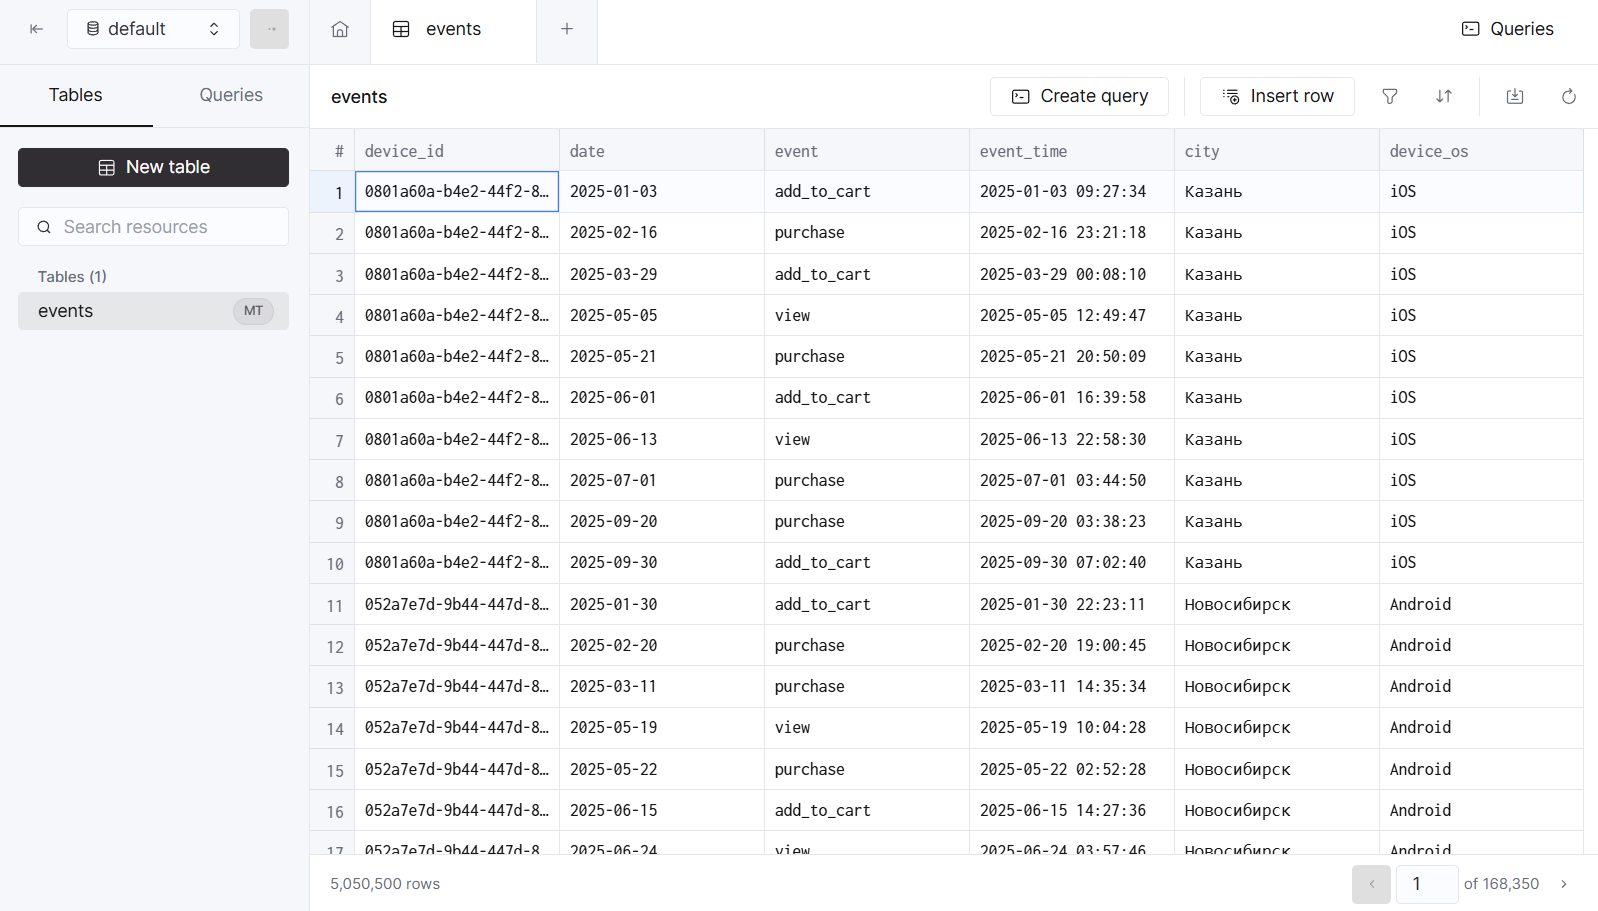